# Projet Fin de Module — Machine Learning
**Dataset :** bienetre.csv — 3 classes : 0=Sain, 1=Modéré, 2=À Risque

Ce notebook couvre : Exploration → Normalisation → PCA → Classification (KNN, Régression Logistique, Arbre de Décision) → KMeans → Grid Search → Validation Croisée

## 1. Exploration du Dataset
Objectif : comprendre la structure des données avant tout traitement.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

In [54]:
# Chargement du dataset
df = pd.read_csv('bienetre.csv')

print(f'Dimensions : {df.shape[0]} individus × {df.shape[1]} variables')
df.head()

Dimensions : 3000 individus × 21 variables


,age,revenu,imc,cholesterol,pression_arterielle,activite_physique,stress,sommeil,alimentation,tabac,...,niveau_education,acces_soins,environnement,soutien_social,satisfaction_vie,acces_sport,consommation_eau,heures_travail,anxiete,target
0,34.58,57125.19,27.47,196.12,133.81,2.86,3.10,7.10,9.00,1.0,...,4.69,7.76,2.60,3.43,6.54,3.03,2.08,49.83,4.80,1
1,34.95,36205.93,29.08,195.76,135.81,4.70,5.17,6.22,5.55,1.0,...,3.56,5.65,5.77,3.13,7.78,3.78,2.21,42.06,6.47,1
2,42.87,27364.05,23.76,187.45,113.19,3.86,4.97,6.78,5.81,0.0,...,2.39,7.48,6.09,4.60,4.58,7.69,1.21,41.92,6.29,1
3,34.59,63335.29,25.02,165.96,117.11,4.46,2.64,7.13,6.94,0.0,...,4.50,7.92,8.24,6.28,9.74,9.26,2.02,30.98,0.00,0
4,56.31,23637.32,30.11,236.20,152.64,0.47,7.72,4.41,2.89,1.0,...,1.61,6.01,5.67,2.22,2.62,2.54,1.30,55.37,10.00,2


In [55]:
# Résumé statistique
df.describe().round(2)

,age,revenu,imc,cholesterol,pression_arterielle,activite_physique,stress,sommeil,alimentation,tabac,...,niveau_education,acces_soins,environnement,soutien_social,satisfaction_vie,acces_sport,consommation_eau,heures_travail,anxiete,target
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,...,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,43.24,38691.95,26.53,196.89,130.21,3.15,5.18,6.47,5.97,0.28,...,3.01,5.98,5.39,5.82,5.80,5.36,1.84,44.77,5.00,1.00
std,13.76,16035.91,4.85,39.56,18.21,1.66,2.26,1.14,2.12,0.45,...,1.01,2.08,1.96,2.28,2.25,2.43,0.65,9.42,2.74,0.82
min,18.00,8000.00,17.00,120.00,90.00,0.00,1.00,3.00,1.00,0.00,...,1.00,1.00,1.00,1.00,1.00,1.00,0.30,21.32,0.00,0.00
25%,31.72,25574.82,22.73,166.43,116.86,1.77,3.27,5.72,4.35,0.00,...,2.21,4.36,3.96,4.03,4.07,3.38,1.34,37.63,2.52,0.00
50%,40.92,37538.75,25.74,192.86,128.04,2.96,5.04,6.60,6.14,0.00,...,3.05,6.12,5.61,5.97,6.01,5.26,1.85,43.32,4.97,1.00
75%,53.58,50909.78,29.85,224.77,142.34,4.49,6.95,7.34,7.69,1.00,...,3.84,7.69,6.94,7.71,7.68,7.46,2.37,50.84,7.27,2.00
max,80.00,86931.08,42.00,310.00,185.00,7.00,10.00,9.00,10.00,1.00,...,5.00,10.00,10.00,10.00,10.00,10.00,3.43,70.00,10.00,2.00


In [56]:
# Valeurs manquantes
missing = df.isnull().sum()
print('Valeurs manquantes par colonne :')
print(missing[missing > 0] if missing.any() else 'Aucune valeur manquante ✓')

Valeurs manquantes par colonne :
Aucune valeur manquante ✓


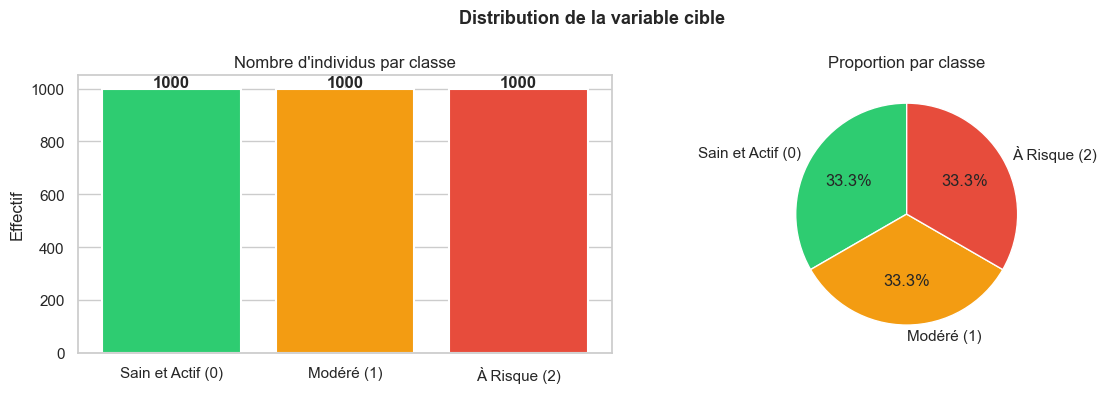

In [57]:
# Répartition des classes
counts = df['target'].value_counts().sort_index()
labels = ['Sain et Actif (0)', 'Modéré (1)', 'À Risque (2)']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
ax1.bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
ax1.set_title('Nombre d\'individus par classe')
ax1.set_ylabel('Effectif')
for i, v in enumerate(counts.values):
    ax1.text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
ax2.pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Proportion par classe')

plt.suptitle('Distribution de la variable cible', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

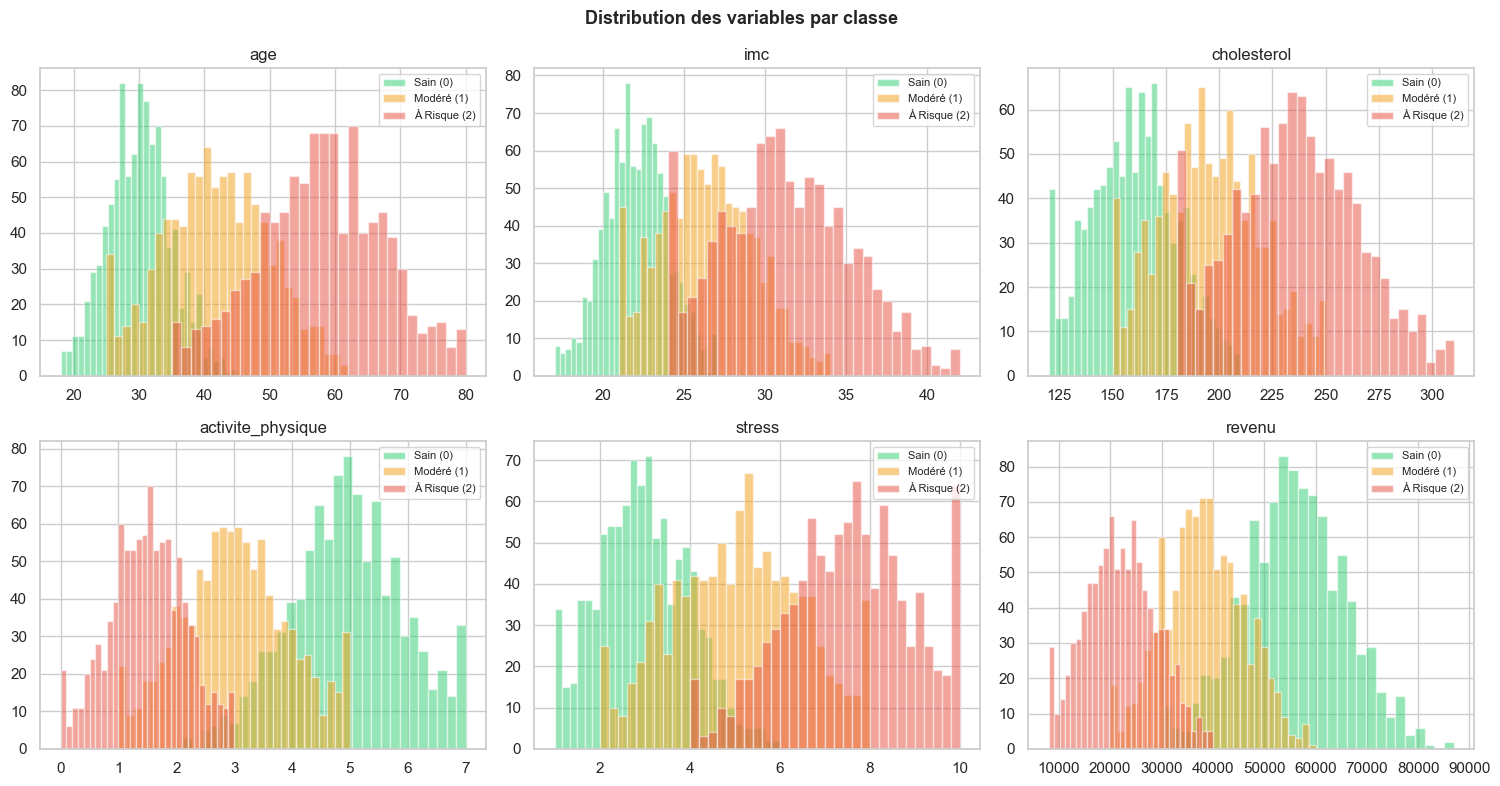

In [58]:
# Distribution de quelques variables clés par classe
features_to_plot = ['age', 'imc', 'cholesterol', 'activite_physique', 'stress', 'revenu']
class_labels = {0: 'Sain (0)', 1: 'Modéré (1)', 2: 'À Risque (2)'}
colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    for cls in [0, 1, 2]:
        axes[i].hist(df[df['target'] == cls][feat], bins=30,
                     alpha=0.5, color=colors[cls], label=class_labels[cls])
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution des variables par classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

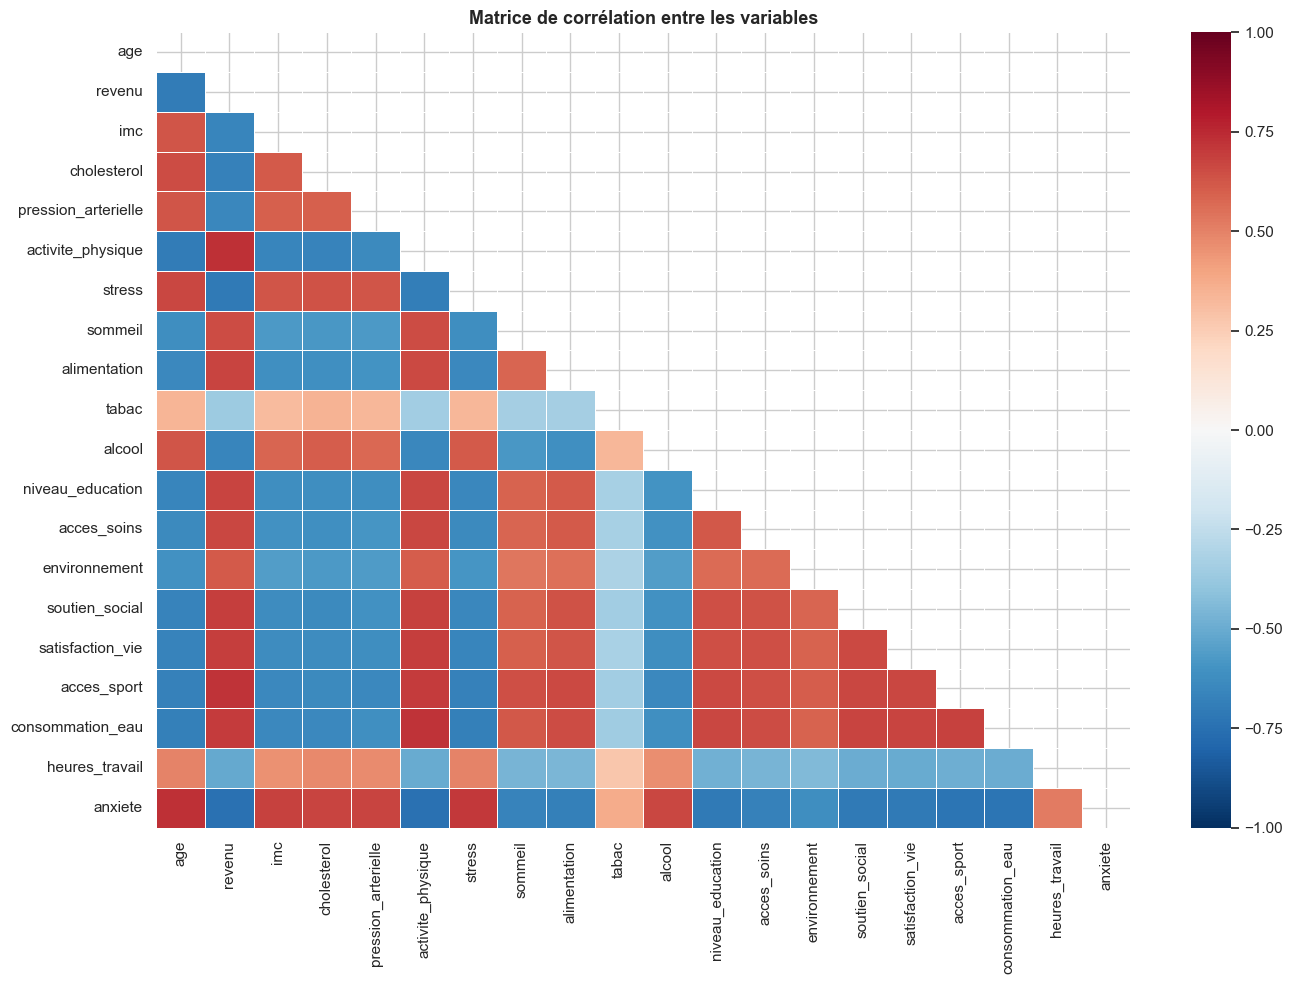

In [59]:
# Matrice de corrélation
plt.figure(figsize=(14, 10))
corr = df.drop('target', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            annot=False, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matrice de corrélation entre les variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Normalisation des Données
**Pourquoi ?** KNN et PCA mesurent des distances. Sans normalisation, les variables avec de grandes plages (ex: revenu) dominent celles avec de petites plages (ex: IMC).

**Comment ?** StandardScaler centre (moyenne=0) et réduit (écart-type=1) chaque variable : `z = (x - μ) / σ`

In [60]:
# Séparation features / cible
X = df.drop('target', axis=1)
y = df['target']

# Normalisation
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('Avant normalisation — age :')
print(f'  Moyenne : {X["age"].mean():.2f}, Écart-type : {X["age"].std():.2f}')
print('Après normalisation — age :')
print(f'  Moyenne : {X_scaled["age"].mean():.4f}, Écart-type : {X_scaled["age"].std():.4f}')

Avant normalisation — age :
  Moyenne : 43.24, Écart-type : 13.76
Après normalisation — age :
  Moyenne : -0.0000, Écart-type : 1.0002


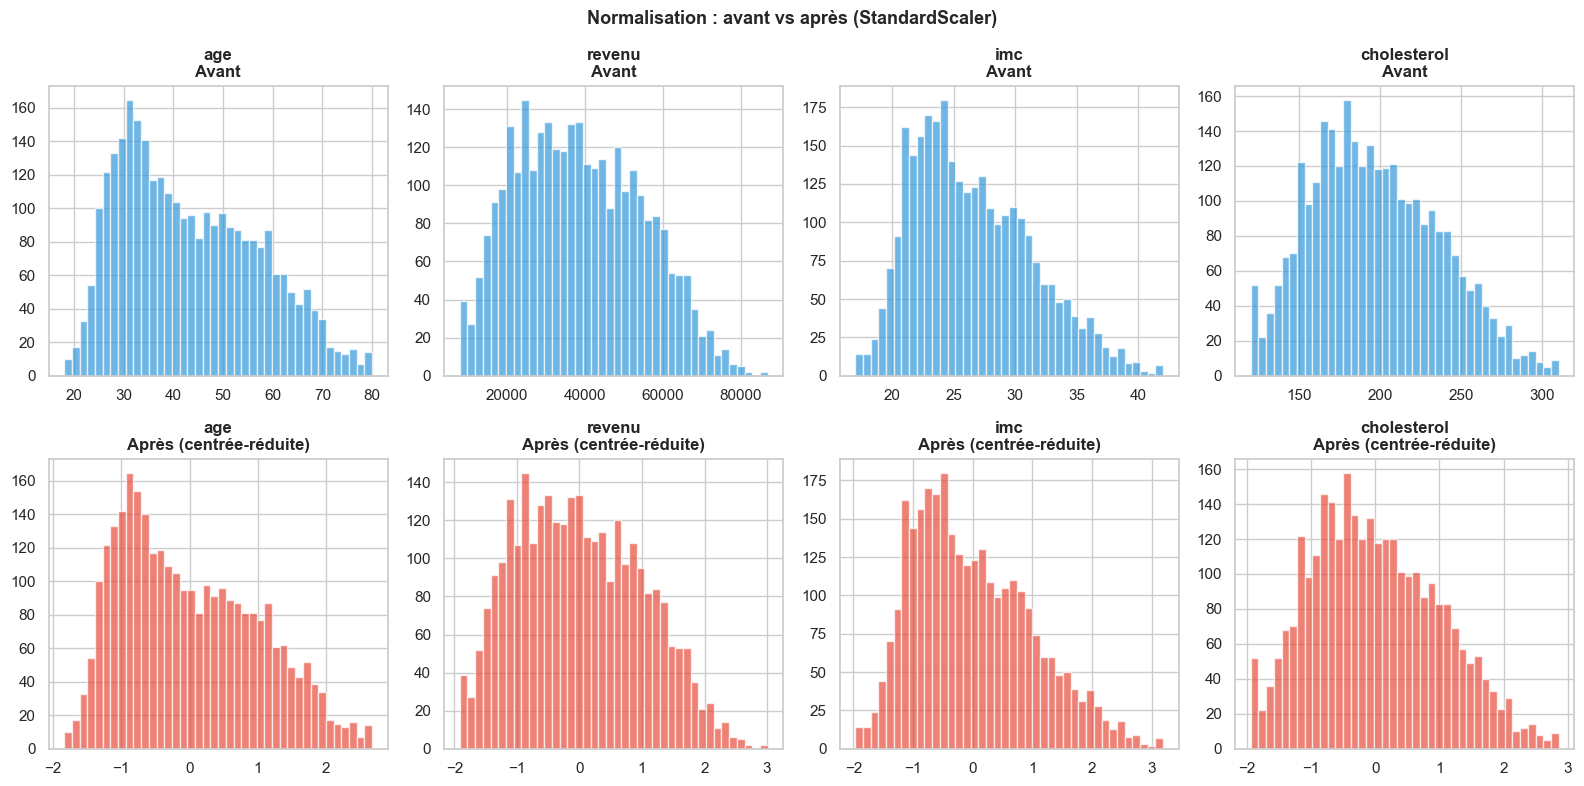

In [61]:
# Comparaison visuelle avant / après pour 4 variables
vars_viz = ['age', 'revenu', 'imc', 'cholesterol']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, var in enumerate(vars_viz):
    # Avant
    axes[0, i].hist(X[var], bins=40, color='#3498db', alpha=0.7, edgecolor='white')
    axes[0, i].set_title(f'{var}\nAvant', fontweight='bold')
    # Après
    axes[1, i].hist(X_scaled[var], bins=40, color='#e74c3c', alpha=0.7, edgecolor='white')
    axes[1, i].set_title(f'{var}\nAprès (centrée-réduite)', fontweight='bold')

plt.suptitle('Normalisation : avant vs après (StandardScaler)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

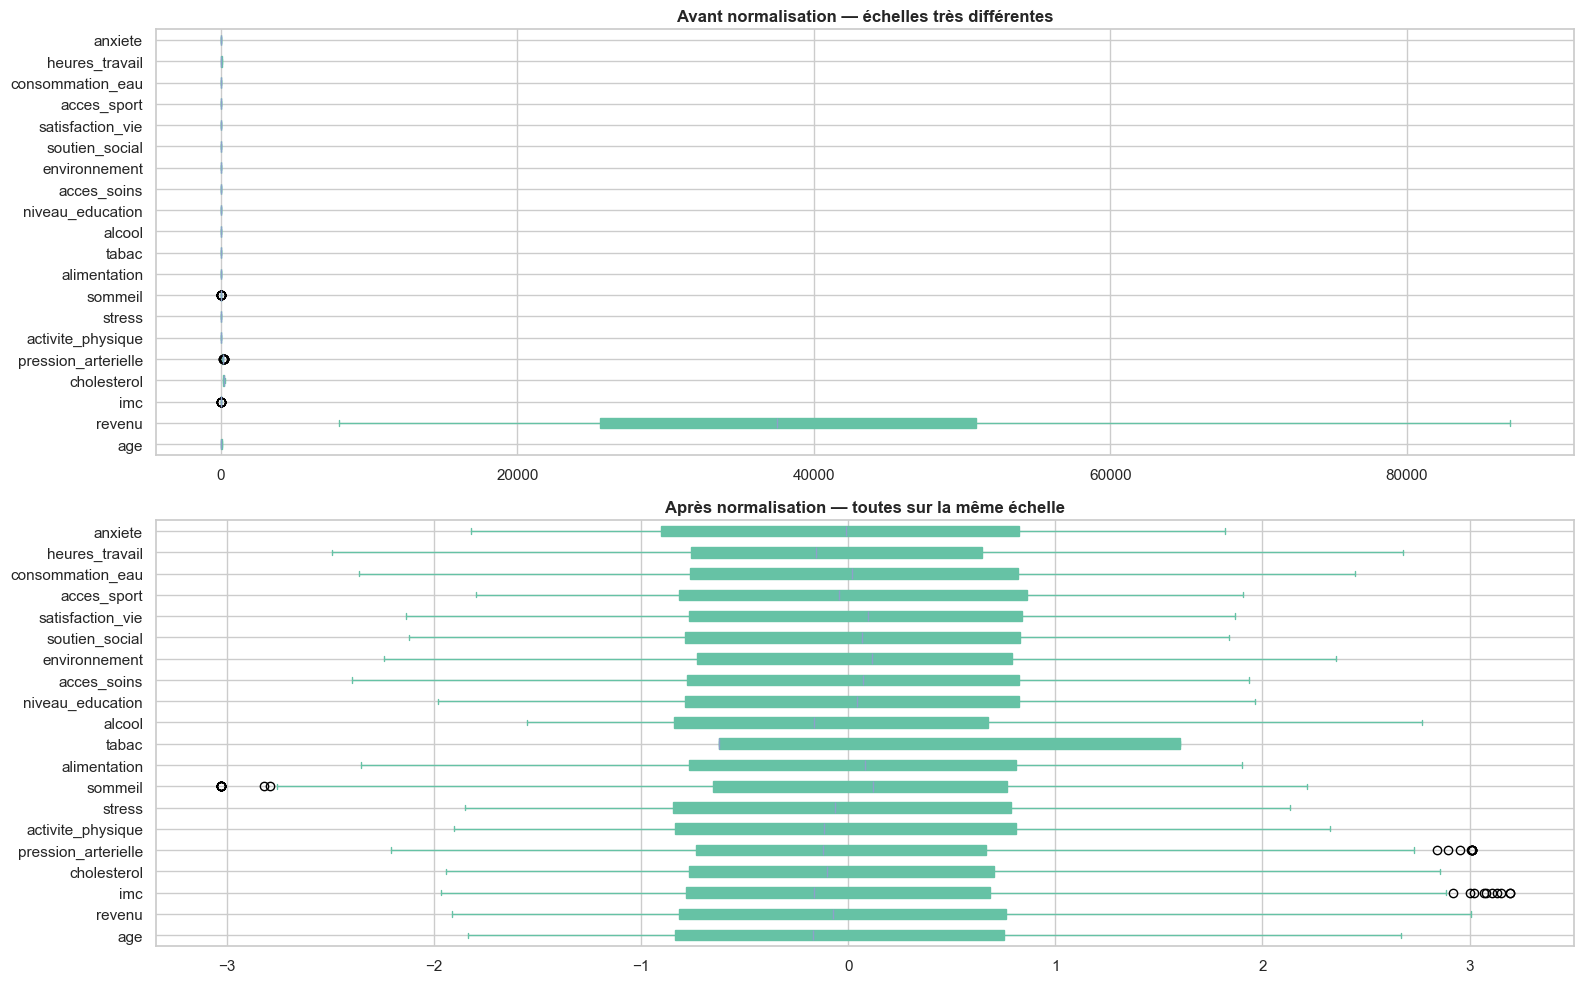

In [62]:
# Boxplots avant / après sur toutes les variables
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

X.plot(kind='box', ax=ax1, vert=False, patch_artist=True)
ax1.set_title('Avant normalisation — échelles très différentes', fontweight='bold')

X_scaled.plot(kind='box', ax=ax2, vert=False, patch_artist=True)
ax2.set_title('Après normalisation — toutes sur la même échelle', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Réduction de Dimensionnalité — PCA
**Pourquoi ?** 20 dimensions = impossible à visualiser. La PCA trouve les 2 directions où les données varient le plus.

**Variance expliquée :** mesure le % d'information conservé après réduction.

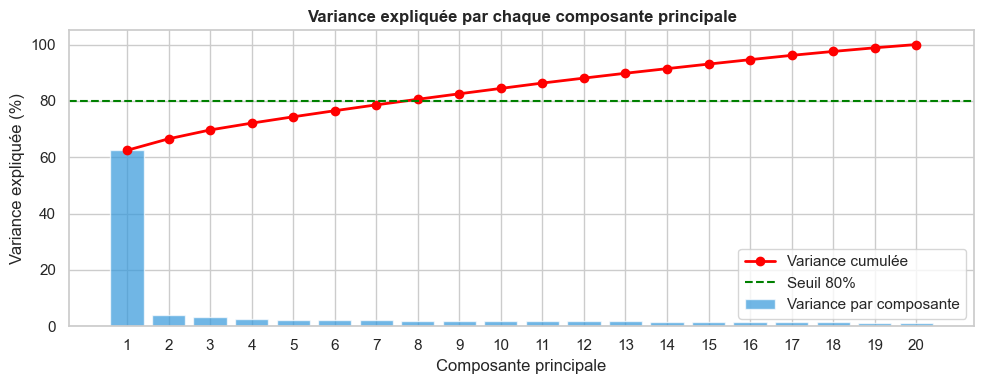

PC1 + PC2 expliquent : 66.5% de la variance
Pour atteindre 80% de variance : 8 composantes nécessaires


In [63]:
# PCA avec toutes les composantes pour analyser la variance
pca_full = PCA()
pca_full.fit(X_scaled)

variance_cumul = np.cumsum(pca_full.explained_variance_ratio_) * 100

plt.figure(figsize=(10, 4))
plt.bar(range(1, 21), pca_full.explained_variance_ratio_ * 100, color='#3498db', alpha=0.7, label='Variance par composante')
plt.plot(range(1, 21), variance_cumul, 'ro-', linewidth=2, label='Variance cumulée')
plt.axhline(y=80, color='green', linestyle='--', label='Seuil 80%')
plt.xlabel('Composante principale')
plt.ylabel('Variance expliquée (%)')
plt.title('Variance expliquée par chaque composante principale', fontweight='bold')
plt.legend()
plt.xticks(range(1, 21))
plt.tight_layout()
plt.show()

n_comp_80 = np.argmax(variance_cumul >= 80) + 1
print(f'PC1 + PC2 expliquent : {variance_cumul[1]:.1f}% de la variance')
print(f'Pour atteindre 80% de variance : {n_comp_80} composantes nécessaires')

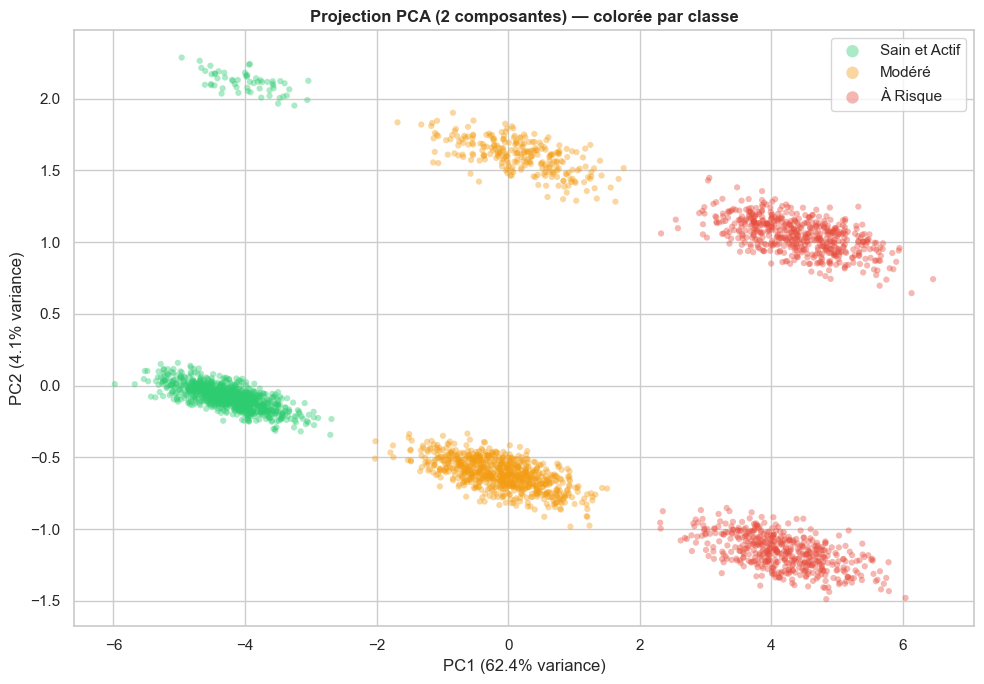

In [64]:
# Projection sur 2 composantes et visualisation
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
labels_map = {0: 'Sain et Actif', 1: 'Modéré', 2: 'À Risque'}

for cls in [0, 1, 2]:
    mask = (y == cls).values
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[cls], label=labels_map[cls],
                alpha=0.4, s=20, edgecolors='none')

plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Projection PCA (2 composantes) — colorée par classe', fontweight='bold')
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()

## 4. Classification Supervisée
On sépare les données en **80% entraînement** et **20% test**. Le modèle apprend sur le train, on évalue sur le test.

In [65]:
# Séparation train / test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Entraînement : {X_train.shape[0]} individus')
print(f'Test         : {X_test.shape[0]} individus')

Entraînement : 2400 individus
Test         : 600 individus


In [66]:
# Fonction utilitaire pour afficher les résultats
def evaluer_modele(nom, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    print(f'\n{'='*50}')
    print(f' {nom}')
    print(f'{'='*50}')
    print(f'Accuracy : {acc:.4f} ({acc*100:.2f}%)')
    print('\nRapport de classification :')
    print(classification_report(y_test, y_pred,
          target_names=['Sain (0)', 'Modéré (1)', 'À Risque (2)']))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Sain', 'Modéré', 'À Risque'],
                yticklabels=['Sain', 'Modéré', 'À Risque'])
    plt.title(f'Matrice de confusion — {nom}', fontweight='bold')
    plt.ylabel('Réel')
    plt.xlabel('Prédit')
    plt.tight_layout()
    plt.show()
    return acc

### 4a. KNN — K Plus Proches Voisins
**Principe :** Pour classer un nouveau point, on regarde ses K voisins les plus proches et on vote à la majorité.


 KNN (K=5)
Accuracy : 1.0000 (100.00%)

Rapport de classification :
              precision    recall  f1-score   support

    Sain (0)       1.00      1.00      1.00       200
  Modéré (1)       1.00      1.00      1.00       200
À Risque (2)       1.00      1.00      1.00       200

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



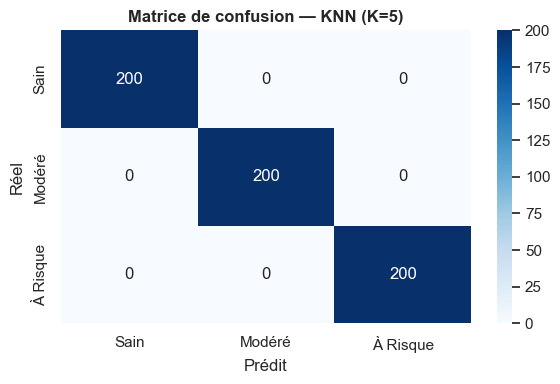

In [67]:
# KNN avec K=5 (valeur par défaut)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

acc_knn = evaluer_modele('KNN (K=5)', y_test, y_pred_knn)

### 4b. Régression Logistique
**Principe :** Le modèle calcule la probabilité d'appartenir à chaque classe via la fonction sigmoid, puis prédit la classe la plus probable.


 Régression Logistique
Accuracy : 1.0000 (100.00%)

Rapport de classification :
              precision    recall  f1-score   support

    Sain (0)       1.00      1.00      1.00       200
  Modéré (1)       1.00      1.00      1.00       200
À Risque (2)       1.00      1.00      1.00       200

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



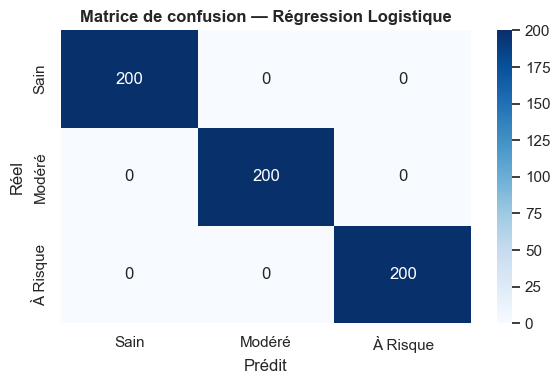

In [68]:
# Régression Logistique
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

acc_lr = evaluer_modele('Régression Logistique', y_test, y_pred_lr)

### 4c. Arbre de Décision
**Principe :** Une série de questions (si IMC > 30 ?) basées sur l'indice de Gini pour séparer les classes.


 Arbre de Décision
Accuracy : 0.9500 (95.00%)

Rapport de classification :
              precision    recall  f1-score   support

    Sain (0)       0.99      0.97      0.98       200
  Modéré (1)       0.90      0.96      0.93       200
À Risque (2)       0.97      0.92      0.94       200

    accuracy                           0.95       600
   macro avg       0.95      0.95      0.95       600
weighted avg       0.95      0.95      0.95       600



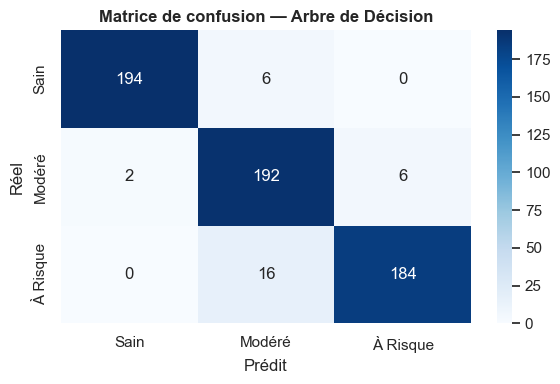

In [69]:
# Arbre de Décision
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

acc_dt = evaluer_modele('Arbre de Décision', y_test, y_pred_dt)

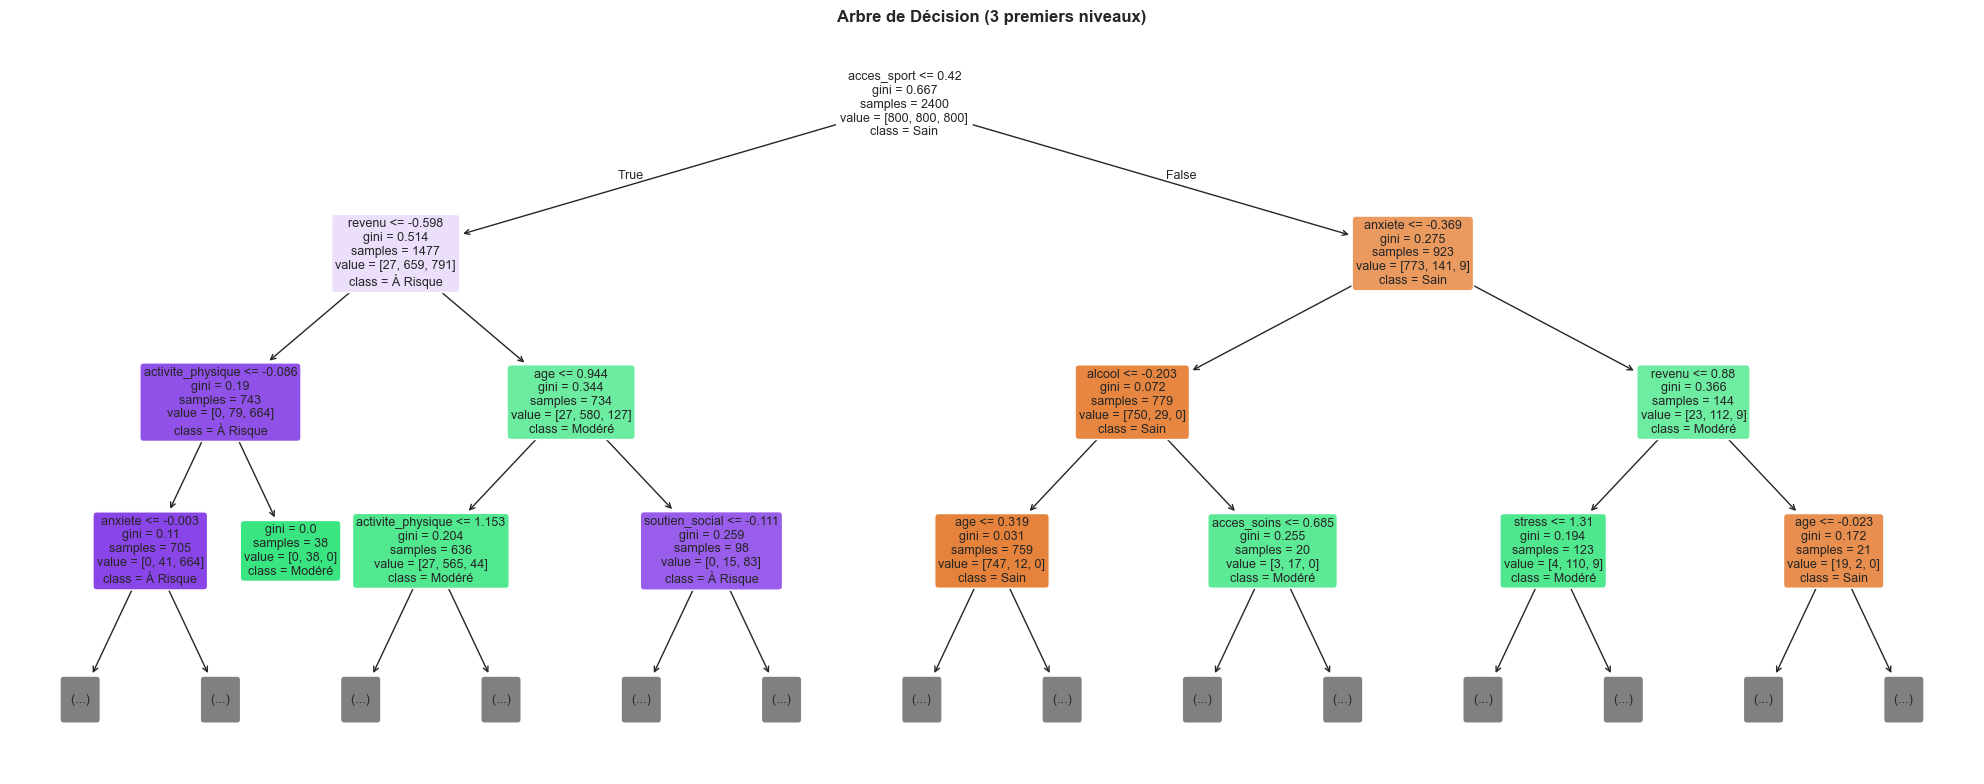

In [70]:
# Visualisation de l'arbre (limité aux 3 premiers niveaux pour la lisibilité)
plt.figure(figsize=(20, 8))
plot_tree(dt, max_depth=3, feature_names=X.columns.tolist(),
          class_names=['Sain', 'Modéré', 'À Risque'],
          filled=True, rounded=True, fontsize=9)
plt.title('Arbre de Décision (3 premiers niveaux)', fontweight='bold')
plt.tight_layout()
plt.show()

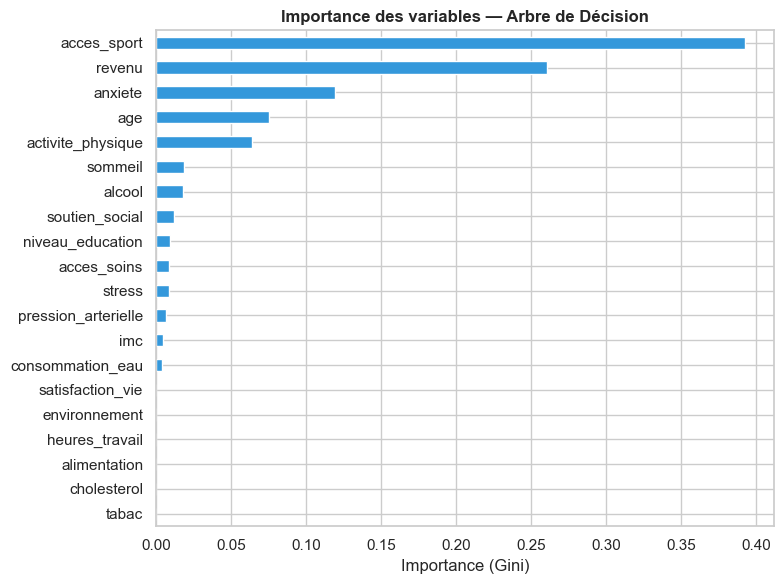

In [71]:
# Importance des variables dans l'arbre
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances_sorted.plot(kind='barh', color='#3498db')
plt.title('Importance des variables — Arbre de Décision', fontweight='bold')
plt.xlabel('Importance (Gini)')
plt.tight_layout()
plt.show()

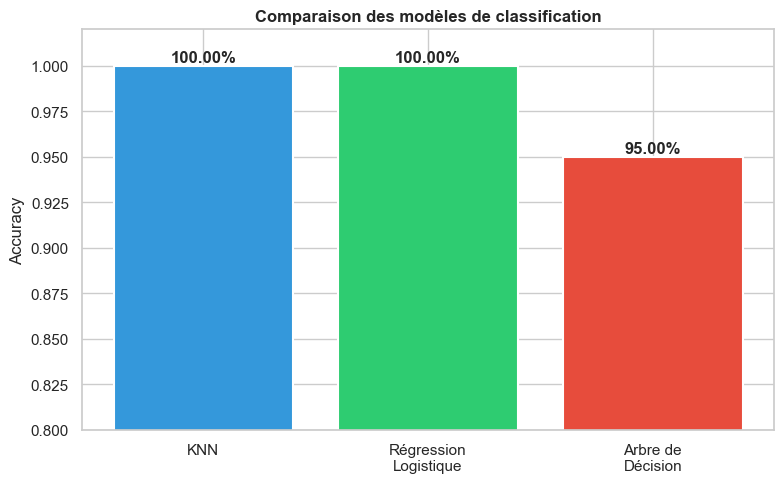

In [72]:
# Comparaison des 3 modèles
modeles = ['KNN', 'Régression\nLogistique', 'Arbre de\nDécision']
accuracies = [acc_knn, acc_lr, acc_dt]
colors_bar = ['#3498db', '#2ecc71', '#e74c3c']

plt.figure(figsize=(8, 5))
bars = plt.bar(modeles, accuracies, color=colors_bar, edgecolor='white', linewidth=1.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc*100:.2f}%', ha='center', fontweight='bold')
plt.ylim(0.8, 1.02)
plt.ylabel('Accuracy')
plt.title('Comparaison des modèles de classification', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Clustering Non Supervisé — KMeans
**Principe :** Regrouper les individus sans utiliser `target`. L'algorithme trouve lui-même des groupes naturels.

On applique KMeans sur la projection PCA (2D) pour pouvoir visualiser.

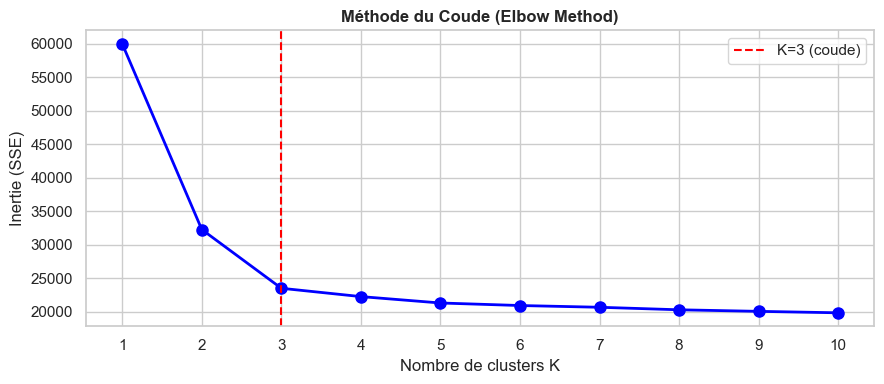

In [73]:
# Méthode du coude pour choisir K optimal
inerties = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inerties.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(K_range, inerties, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', label='K=3 (coude)')
plt.xlabel('Nombre de clusters K')
plt.ylabel('Inertie (SSE)')
plt.title('Méthode du Coude (Elbow Method)', fontweight='bold')
plt.legend()
plt.xticks(K_range)
plt.tight_layout()
plt.show()

Score de silhouette : 0.3189 (proche de 1 = bon clustering)


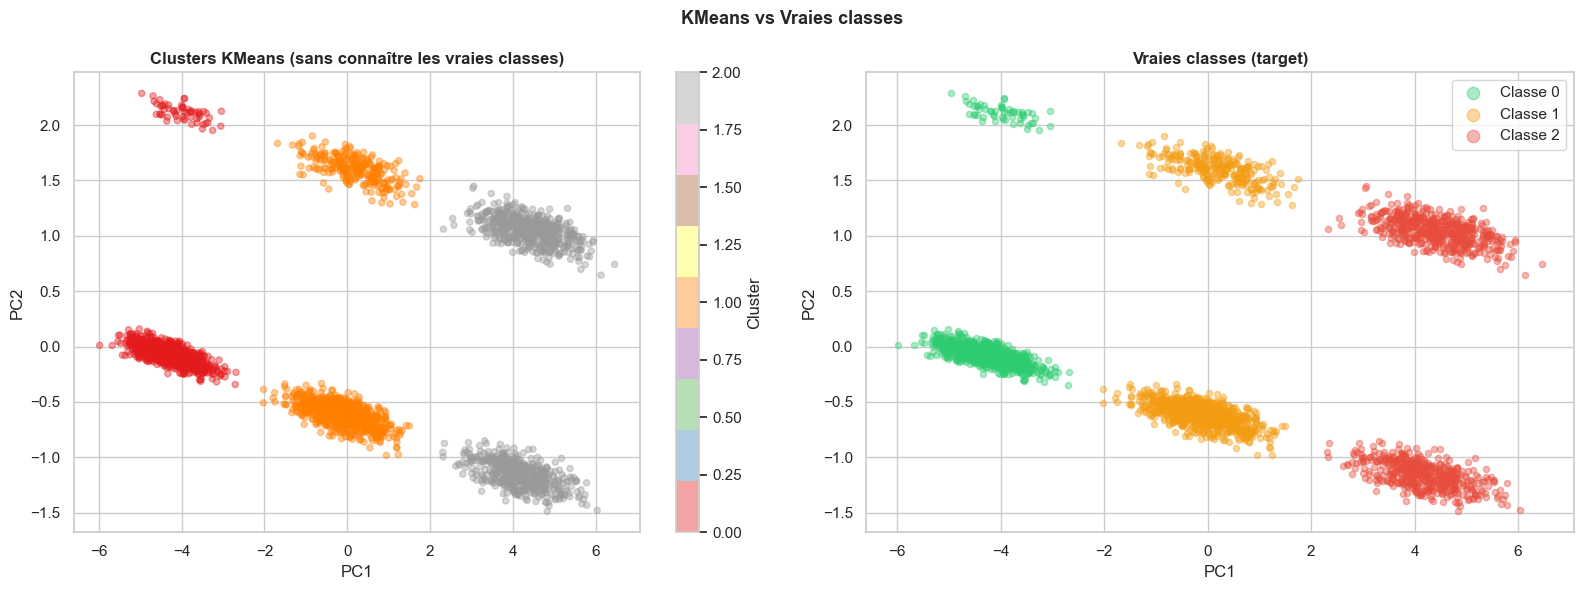

In [74]:
# KMeans avec K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, clusters)
print(f'Score de silhouette : {sil_score:.4f} (proche de 1 = bon clustering)')

# Visualisation sur la projection PCA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors_cls = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}

# Clusters trouvés par KMeans
scatter = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Set1', alpha=0.4, s=20)
ax1.set_title('Clusters KMeans (sans connaître les vraies classes)', fontweight='bold')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
plt.colorbar(scatter, ax=ax1, label='Cluster')

# Vraies classes
for cls in [0, 1, 2]:
    mask = (y == cls).values
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors_cls[cls], label=f'Classe {cls}', alpha=0.4, s=20)
ax2.set_title('Vraies classes (target)', fontweight='bold')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.legend(markerscale=2)

plt.suptitle('KMeans vs Vraies classes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Optimisation des Hyperparamètres — Grid Search
**Principe :** Tester systématiquement toutes les combinaisons d'hyperparamètres et garder la meilleure, évaluée par validation croisée.

In [75]:
# Grid Search sur KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_knn.fit(X_train, y_train)

print('Meilleurs paramètres KNN :', grid_knn.best_params_)
print(f'Meilleur score (CV)       : {grid_knn.best_score_:.4f}')

# Évaluation sur le test
y_pred_best_knn = grid_knn.predict(X_test)
print(f'Accuracy sur test         : {accuracy_score(y_test, y_pred_best_knn):.4f}')

Meilleurs paramètres KNN : {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Meilleur score (CV)       : 1.0000
Accuracy sur test         : 1.0000


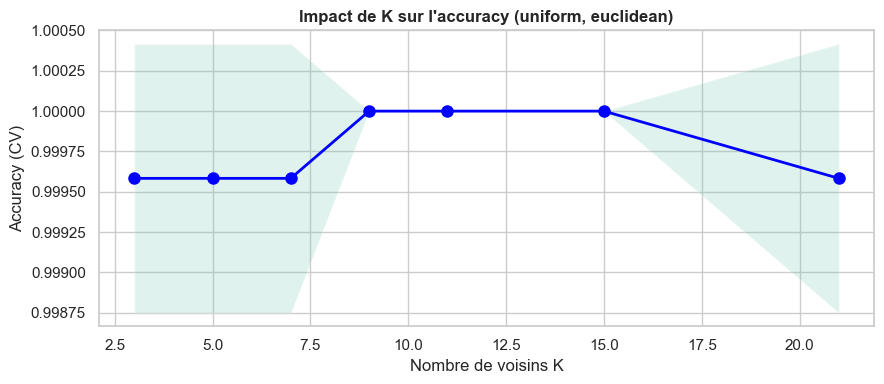

In [76]:
# Visualisation : impact de K sur l'accuracy
results = pd.DataFrame(grid_knn.cv_results_)
knn_uniform_eucl = results[
    (results['param_weights'] == 'uniform') &
    (results['param_metric'] == 'euclidean')
].sort_values('param_n_neighbors')

plt.figure(figsize=(9, 4))
plt.plot(knn_uniform_eucl['param_n_neighbors'],
         knn_uniform_eucl['mean_test_score'], 'bo-', linewidth=2, markersize=8)
plt.fill_between(knn_uniform_eucl['param_n_neighbors'],
                 knn_uniform_eucl['mean_test_score'] - knn_uniform_eucl['std_test_score'],
                 knn_uniform_eucl['mean_test_score'] + knn_uniform_eucl['std_test_score'],
                 alpha=0.2)
plt.xlabel('Nombre de voisins K')
plt.ylabel('Accuracy (CV)')
plt.title('Impact de K sur l\'accuracy (uniform, euclidean)', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Validation Croisée (K-Fold Cross-Validation)
**Principe :** Découper les données en K parties (folds). Pour chaque fold, entraîner sur K-1 folds et tester sur le restant. Répéter K fois → moyenne des scores.

Cela donne une estimation plus robuste et stable de la performance réelle du modèle.

In [77]:
# Validation croisée sur les 3 modèles (5 folds)
modeles_cv = {
    'KNN optimisé': grid_knn.best_estimator_,
    'Régression Logistique': LogisticRegression(max_iter=1000, random_state=42),
    'Arbre de Décision': DecisionTreeClassifier(max_depth=5, random_state=42)
}

resultats_cv = {}
print('Validation croisée (5 folds) :\n')

for nom, modele in modeles_cv.items():
    scores = cross_val_score(modele, X_scaled, y, cv=5, scoring='accuracy')
    resultats_cv[nom] = scores
    print(f'{nom}')
    print(f'  Scores : {[f"{s:.4f}" for s in scores]}')
    print(f'  Moyenne : {scores.mean():.4f} ± {scores.std():.4f}\n')

Validation croisée (5 folds) :

KNN optimisé
  Scores : ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
  Moyenne : 1.0000 ± 0.0000

Régression Logistique
  Scores : ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
  Moyenne : 1.0000 ± 0.0000

Arbre de Décision
  Scores : ['0.9517', '0.9600', '0.9450', '0.9400', '0.9417']
  Moyenne : 0.9477 ± 0.0073



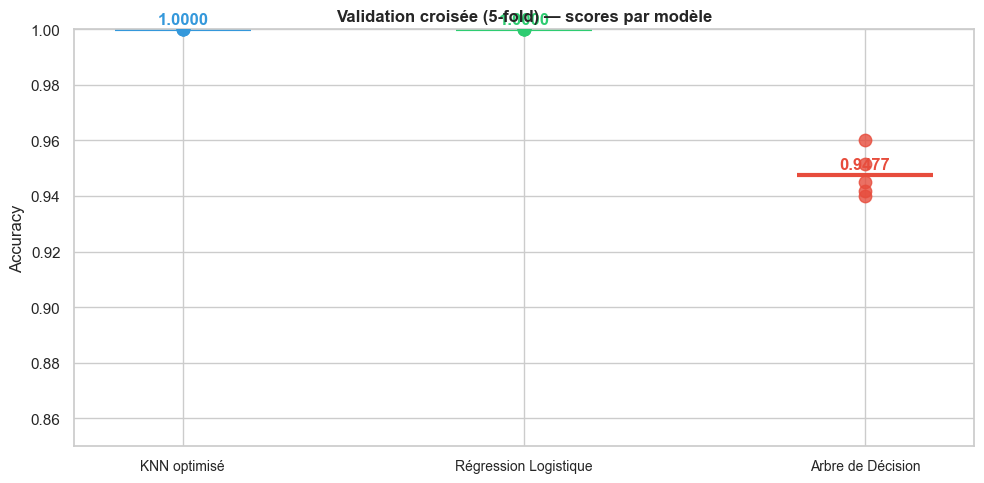

In [78]:
# Visualisation des scores de validation croisée
fig, ax = plt.subplots(figsize=(10, 5))

noms = list(resultats_cv.keys())
positions = range(len(noms))
colors_cv = ['#3498db', '#2ecc71', '#e74c3c']

for i, (nom, scores) in enumerate(resultats_cv.items()):
    ax.scatter([i] * len(scores), scores, color=colors_cv[i], zorder=5, s=80, alpha=0.8)
    ax.hlines(scores.mean(), i - 0.2, i + 0.2, colors=colors_cv[i], linewidth=3)
    ax.text(i, scores.mean() + 0.002, f'{scores.mean():.4f}', ha='center',
            fontweight='bold', color=colors_cv[i])

ax.set_xticks(positions)
ax.set_xticklabels(noms, fontsize=10)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.85, 1.0)
ax.set_title('Validation croisée (5-fold) — scores par modèle', fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusion

| Modèle | Accuracy Test | Accuracy CV (moyenne ± std) |
|---|---|---|
| KNN optimisé | *voir cellule Grid Search* | *voir cellule CV* |
| Régression Logistique | *voir cellule évaluation* | *voir cellule CV* |
| Arbre de Décision | *voir cellule évaluation* | *voir cellule CV* |

**Observations :**
- La normalisation est indispensable pour KNN et PCA.
- La PCA montre que les 3 classes sont globalement séparables en 2D.
- KMeans retrouve des groupes proches des vraies classes sans les avoir vues.
- Le Grid Search améliore KNN en trouvant le K optimal.
- La validation croisée donne une estimation fiable et stable des performances.